In [2154]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np

import random

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2175]:
import numpy as np

def MFC(u, y, reference, parameters):
    # Inputs: u, y, last ref, last dref, parameters (contains tsamp, alpha, L)
    # Output: control signal uc
    if not hasattr(MFC, 'integral_error'):
        MFC.integral_error=0.

    alpha = parameters['alpha']
    tsamp = parameters['tsamp']
    L = parameters['L']
    L=L+tsamp
    Kp = parameters['Kp']
    Ki = parameters['Ki']
    
    ref = reference['ref']
    dref = reference['dref']
    
    # sigma = np.linspace(0, L, num=int(L / tsamp) )
    sigma=np.arange(0,L,tsamp)
    y_sigma = y
    u_sigma = u
    e_last = y[-1] - ref
    e=y-ref
    MFC.integral_error=e_last*tsamp

    term_y = (L - 2 * sigma) * y_sigma
    term_u = alpha * sigma * (L - sigma) * u_sigma
    
    to_be_integrated = (term_y + term_u)
    
    Phi = -6/(L**3)*np.trapezoid(to_be_integrated,dx=tsamp)
    # print('Phi',Phi)

    # print(L)
    # print(sigma)
    # print(y)
    # print(u)
    # print(Phi)
    # print(e)
    # # #second way to compute it
    # to_be_integrated=dref-alpha*u-Kp*e
    # Phi = 1/(L)*np.trapezoid(to_be_integrated,dx=tsamp)

    uc = Phi - dref + Kp * e_last+MFC.integral_error*Ki
    uc = -uc / alpha

    return uc

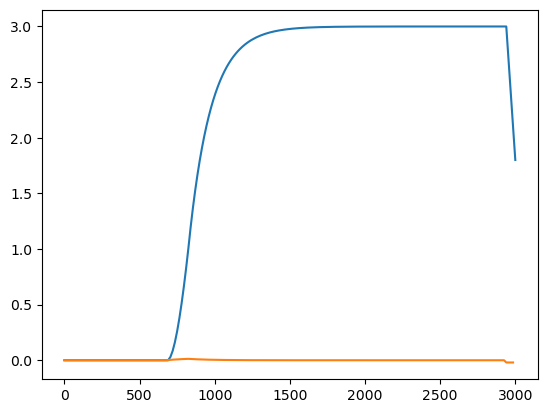

In [2201]:

# Parameters
N = 200
tsamp = 15  # Sampling time
L = 3* tsamp  # L parameter for MFC
endtime = tsamp * N
timevector = np.arange(0, endtime + tsamp, tsamp)

# System parameters (replicating MATLAB's sys.A, sys.B, etc.)
sys_A = 0.99998
sys_B = 0.12565
sys_C = 1.
sys_D = 0.

# Generate input and initialize output
u = np.zeros_like(timevector)*1.
y = np.zeros_like(timevector)*1.
# Initialize states (replicating x matrix)
x = np.zeros((len(timevector)))

for k in range(len(timevector)):
    y[k] = sys_C * x[k] + sys_D * u[k]
    if k < len(timevector) - 1:
        x[k + 1] = sys_A * x[k] + sys_B * u[k]

# Setpoint generation
setpoint = 3. * np.ones_like(timevector)

# Reference trajectory with inertial compensation (replicating MATLAB's G_inertialComp)
ref = setpoint.copy()
#faire une reference et la derrive de la ref
dref = np.zeros_like(ref)
from scipy import signal
lti = signal.lti([3.0], [150.0, 1.0])
t, yref = signal.step(lti,T=timevector)
ref=np.zeros_like(setpoint)
ref[50:]=yref[:-50]
ref=np.convolve(ref,np.ones((10,))/10 ,mode="same")

dref=np.diff(ref)/tsamp

plt.plot(timevector,ref)
plt.plot(timevector[:-1],dref)


In [2202]:
Kp=1.2
Ki=.01
alpha=1
parameters={"L" : L, "alpha" : alpha,"tsamp" : tsamp,"Kp" : Kp,"Ki" : Ki}
MFC.integral_error=0.
# Main loop
n = len(np.arange(0, L + tsamp, tsamp))
a = 0
k_a = np.where(abs(timevector - a) < 1e-6)[0][0]
b = a + L
k_b = np.where(abs(timevector - b) < 1e-6)[0][0]
eii=0
for i in np.arange(len(timevector) - n-2):
    reference_ref = ref[k_b]
    reference_dref = dref[k_b]
    
    # Error calculation (replicating e(i))
    e_i = y[k_b] - reference_ref*1.
    eii+=e_i*tsamp


    
    # Call MFC function
    uc = MFC(u[k_a:k_b+1], y[k_a:k_b+1], {'ref': reference_ref, 'dref': reference_dref}, parameters)
    # uc=-e_i*Kp-Ki*eii
    # Update system states and outputs
    u[k_b+1]=uc
    y[k_b + 1] = sys_C * x[k_b + 1] + sys_D * u[k_b+1]#+np.random.normal(0,0.2)
    x[k_b + 2] = sys_A * x[k_b + 1] + sys_B * u[k_b+1]#+np.random.normal(0,0.105)
    
    # Update variables for next iteration
    a += tsamp
    b += tsamp
    k_a = np.where(abs(timevector - a) < 1e-6)[0][0]
    k_b = np.where(abs(timevector - b) < 1e-6)[0][0]

y[k_b + 1]=y[k_b]
y[k_b + 2]=y[k_b + 1]


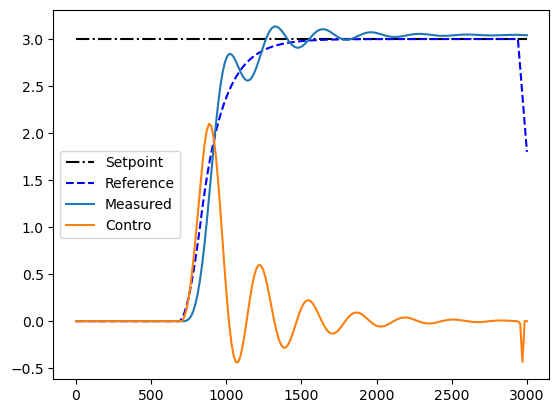

In [2203]:
# Plots
plt.figure()
plt.plot(timevector, setpoint, '-.k', label='Setpoint')
plt.plot(timevector, ref, '--b', label='Reference')
plt.plot(timevector, y, label='Measured')
plt.plot(timevector, u, label='Control')
plt.legend(['Setpoint', 'Reference', 'Measured',"Contro"])
# plt.figure()
# plt.plot(e, label='Error')
# plt.title('Error')

plt.show()